In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2025-26/gws/merged_gw.csv"
gw = pd.read_csv(url)

season = gw.groupby(['name','position','team']).agg(
    goals_scored=('goals_scored','sum'),
    expected_goals=('expected_goals','sum'),
    minutes=('minutes','sum'),
    starts=('starts','sum')
).reset_index()

strikers = season[season['position'] == 'FWD'].copy()
print(strikers.shape)
strikers.sort_values('minutes', ascending=False).head(15)

(99, 7)


,name,position,team,goals_scored,expected_goals,minutes,starts
369,Jarrod Bowen,FWD,West Ham,9,7.22,3406,38
318,Igor Thiago Nascimento Rodrigues,FWD,Brentford,22,20.60,3282,37
232,Erling Haaland,FWD,Man City,27,25.50,2953,34
656,Ollie Watkins,FWD,Aston Villa,16,15.40,2833,33
258,Francisco Evanilson de Lima Barbosa,FWD,Bournemouth,6,10.64,2741,32
197,Dominic Calvert-Lewin,FWD,Leeds,14,15.57,2721,30
429,João Pedro Junqueira de Jesus,FWD,Chelsea,15,14.91,2658,31
315,Igor Jesus Maciel da Cruz,FWD,Nott'm Forest,6,6.48,2293,28
173,Danny Welbeck,FWD,Brighton,13,12.36,2249,26
822,Viktor Gyökeres,FWD,Arsenal,14,12.26,2217,26


In [3]:
# Keep only strikers with meaningful playing time
strikers_filtered = strikers[strikers['minutes'] >= 500].copy()
print(f"Strikers before filter: {len(strikers)}")
print(f"Strikers after filter: {len(strikers_filtered)}")

strikers_filtered.sort_values('minutes', ascending=False)

Strikers before filter: 99
Strikers after filter: 44


,name,position,team,goals_scored,expected_goals,minutes,starts
369,Jarrod Bowen,FWD,West Ham,9,7.22,3406,38
318,Igor Thiago Nascimento Rodrigues,FWD,Brentford,22,20.60,3282,37
232,Erling Haaland,FWD,Man City,27,25.50,2953,34
656,Ollie Watkins,FWD,Aston Villa,16,15.40,2833,33
258,Francisco Evanilson de Lima Barbosa,FWD,Bournemouth,6,10.64,2741,32
197,Dominic Calvert-Lewin,FWD,Leeds,14,15.57,2721,30
429,João Pedro Junqueira de Jesus,FWD,Chelsea,15,14.91,2658,31
315,Igor Jesus Maciel da Cruz,FWD,Nott'm Forest,6,6.48,2293,28
173,Danny Welbeck,FWD,Brighton,13,12.36,2249,26
822,Viktor Gyökeres,FWD,Arsenal,14,12.26,2217,26


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = strikers_filtered[['expected_goals']]
y = strikers_filtered['goals_scored']

reg = LinearRegression()
reg.fit(X, y)

strikers_filtered['predicted_goals'] = reg.predict(X)
strikers_filtered['residual'] = strikers_filtered['goals_scored'] - strikers_filtered['predicted_goals']

print("Slope:", reg.coef_[0])
print("Intercept:", reg.intercept_)
print("R²:", r2_score(y, strikers_filtered['predicted_goals']))

Slope: 1.07097912980974
Intercept: -0.5699756131696256
R²: 0.8938929896387243


In [5]:
ranked = strikers_filtered.sort_values('residual')

print("Biggest UNDERperformers (wasting chances):")
print(ranked[['name','team','goals_scored','expected_goals','residual']].head(10).to_string(index=False))

print("\nBiggest OVERperformers (clinical finishers):")
print(ranked[['name','team','goals_scored','expected_goals','residual']].tail(10).to_string(index=False))

Biggest UNDERperformers (wasting chances):
                               name           team  goals_scored  expected_goals  residual
Francisco Evanilson de Lima Barbosa    Bournemouth             6           10.64 -4.825242
                         Liam Delap        Chelsea             1            4.54 -3.292270
               Jean-Philippe Mateta Crystal Palace            12           14.42 -2.873543
             Raúl Jiménez Rodríguez         Fulham             9           11.58 -2.831963
                     Tolu Arokodare         Wolves             3            5.49 -2.309700
              Dominic Calvert-Lewin          Leeds            14           15.57 -2.105169
             Rodrigo Muniz Carvalho         Fulham             1            3.30 -1.964256
                        Yoane Wissa      Newcastle             1            3.13 -1.782189
               Jørgen Strand Larsen         Wolves             1            3.05 -1.696511
                       Lukas Nmecha          Le

In [6]:
strikers_filtered['goals_per_90'] = strikers_filtered['goals_scored'] / strikers_filtered['minutes'] * 90
strikers_filtered['xg_per_90'] = strikers_filtered['expected_goals'] / strikers_filtered['minutes'] * 90

strikers_filtered[['name','team','minutes','goals_per_90','xg_per_90']].sort_values('minutes', ascending=False).head(10)

,name,team,minutes,goals_per_90,xg_per_90
369,Jarrod Bowen,West Ham,3406,0.237816,0.190781
318,Igor Thiago Nascimento Rodrigues,Brentford,3282,0.603291,0.564899
232,Erling Haaland,Man City,2953,0.822892,0.777176
656,Ollie Watkins,Aston Villa,2833,0.508295,0.489234
258,Francisco Evanilson de Lima Barbosa,Bournemouth,2741,0.197008,0.349362
197,Dominic Calvert-Lewin,Leeds,2721,0.463065,0.514994
429,João Pedro Junqueira de Jesus,Chelsea,2658,0.507901,0.504853
315,Igor Jesus Maciel da Cruz,Nott'm Forest,2293,0.235499,0.254339
173,Danny Welbeck,Brighton,2249,0.520231,0.494620
822,Viktor Gyökeres,Arsenal,2217,0.568336,0.497700


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X90 = strikers_filtered[['xg_per_90']]
y90 = strikers_filtered['goals_per_90']

reg90 = LinearRegression()
reg90.fit(X90, y90)

strikers_filtered['predicted_goals_per_90'] = reg90.predict(X90)
strikers_filtered['residual_per_90'] = strikers_filtered['goals_per_90'] - strikers_filtered['predicted_goals_per_90']

print("Slope:", reg90.coef_[0])
print("Intercept:", reg90.intercept_)
print("R²:", r2_score(y90, strikers_filtered['predicted_goals_per_90']))

Slope: 1.0564961102291024
Intercept: -0.041216197966081114
R²: 0.5894899462838951


In [8]:
ranked90 = strikers_filtered.sort_values('residual_per_90')

print("Biggest UNDERperformers per 90 (wasting chances):")
print(ranked90[['name','team','minutes','goals_per_90','xg_per_90','residual_per_90']].head(10).to_string(index=False))

print("\nBiggest OVERperformers per 90 (clinical finishers):")
print(ranked90[['name','team','minutes','goals_per_90','xg_per_90','residual_per_90']].tail(10).to_string(index=False))

Biggest UNDERperformers per 90 (wasting chances):
                               name          team  minutes  goals_per_90  xg_per_90  residual_per_90
                        Yoane Wissa     Newcastle      517      0.174081   0.544874        -0.360360
                         Liam Delap       Chelsea     1092      0.082418   0.374176        -0.271682
                        Kai Havertz       Arsenal      577      0.311958   0.516291        -0.192285
             Rodrigo Muniz Carvalho        Fulham      987      0.091185   0.300912        -0.185511
                     Tolu Arokodare        Wolves     1402      0.192582   0.352425        -0.138538
Francisco Evanilson de Lima Barbosa   Bournemouth     2741      0.197008   0.349362        -0.130875
                         Chris Wood Nott'm Forest      896      0.301339   0.430915        -0.112705
               Jørgen Strand Larsen        Wolves     1399      0.064332   0.196212        -0.101749
                       Lukas Nmecha      

In [9]:
# Raise minimum minutes threshold from 500 to 900 (~10 full matches)
strikers_filtered = strikers[strikers['minutes'] >= 900].copy()
print(f"Strikers before filter: {len(strikers)}")
print(f"Strikers after filter (900+ mins): {len(strikers_filtered)}")

# Recompute per-90 stats on the filtered group
strikers_filtered['goals_per_90'] = strikers_filtered['goals_scored'] / strikers_filtered['minutes'] * 90
strikers_filtered['xg_per_90'] = strikers_filtered['expected_goals'] / strikers_filtered['minutes'] * 90

# Re-fit the regression on this cleaner group
X90 = strikers_filtered[['xg_per_90']]
y90 = strikers_filtered['goals_per_90']

reg90 = LinearRegression()
reg90.fit(X90, y90)

strikers_filtered['predicted_goals_per_90'] = reg90.predict(X90)
strikers_filtered['residual_per_90'] = strikers_filtered['goals_per_90'] - strikers_filtered['predicted_goals_per_90']

print("Slope:", reg90.coef_[0])
print("Intercept:", reg90.intercept_)
print("R²:", r2_score(y90, strikers_filtered['predicted_goals_per_90']))

Strikers before filter: 99
Strikers after filter (900+ mins): 35
Slope: 1.0868583187241783
Intercept: -0.038138865473063555
R²: 0.6830528156412716


In [10]:
ranked90 = strikers_filtered.sort_values('residual_per_90')

print("Biggest UNDERperformers per 90 (900+ minutes only):")
print(ranked90[['name','team','minutes','starts','goals_per_90','xg_per_90','residual_per_90']].head(10).to_string(index=False))

print("\nBiggest OVERperformers per 90 (900+ minutes only):")
print(ranked90[['name','team','minutes','starts','goals_per_90','xg_per_90','residual_per_90']].tail(10).to_string(index=False))

Biggest UNDERperformers per 90 (900+ minutes only):
                               name           team  minutes  starts  goals_per_90  xg_per_90  residual_per_90
                         Liam Delap        Chelsea     1092      12      0.082418   0.374176        -0.286120
             Rodrigo Muniz Carvalho         Fulham      987      10      0.091185   0.300912        -0.197724
                     Tolu Arokodare         Wolves     1402      13      0.192582   0.352425        -0.152315
Francisco Evanilson de Lima Barbosa    Bournemouth     2741      32      0.197008   0.349362        -0.144559
                       Lukas Nmecha          Leeds     1065      10      0.507042   0.612676        -0.120711
               Jean-Philippe Mateta Crystal Palace     2210      25      0.488688   0.587240        -0.111420
               Jørgen Strand Larsen         Wolves     1399      14      0.064332   0.196212        -0.110784
             Raúl Jiménez Rodríguez         Fulham     2183      27 

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


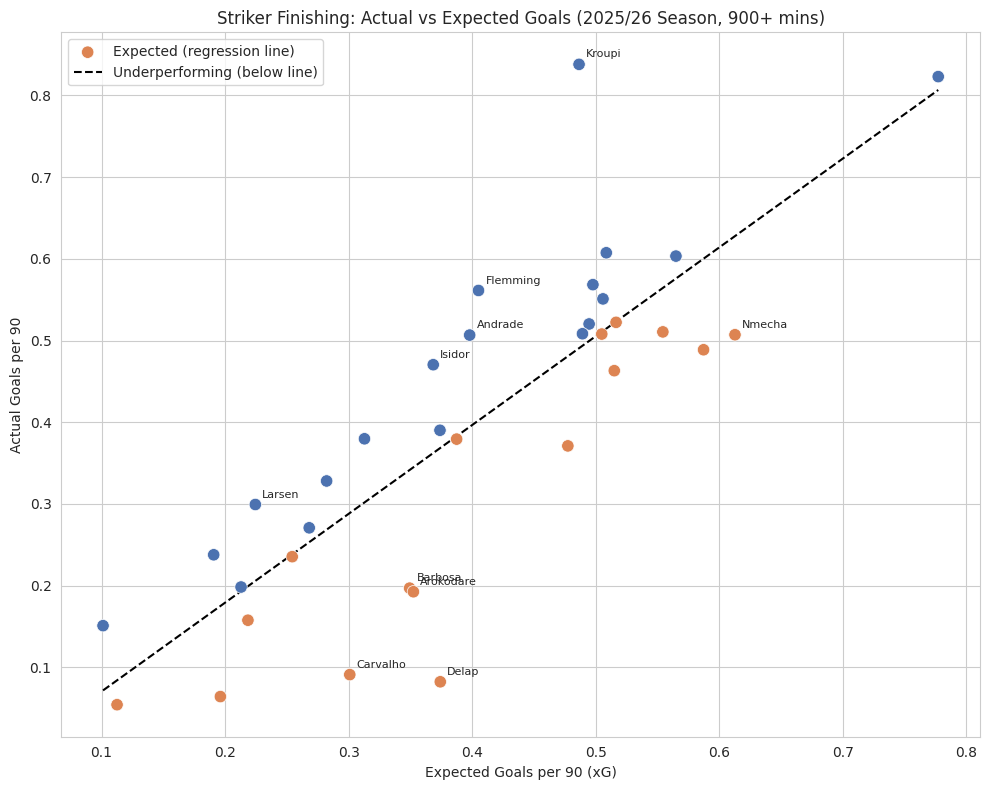

In [11]:
plt.figure(figsize=(10,8))

# Color points by whether they over or underperform
colors = ['#DD8452' if r < 0 else '#4C72B0' for r in strikers_filtered['residual_per_90']]

plt.scatter(strikers_filtered['xg_per_90'], strikers_filtered['goals_per_90'],
            c=colors, s=80, edgecolor='white', linewidth=0.5, zorder=3)

# Draw the regression line
x_line = np.linspace(strikers_filtered['xg_per_90'].min(), strikers_filtered['xg_per_90'].max(), 100)
y_line = reg90.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, label='Expected (regression line)', zorder=2)

# Label the biggest over/underperformers
extremes = pd.concat([ranked90.head(5), ranked90.tail(5)])
for _, row in extremes.iterrows():
    plt.annotate(row['name'].split()[-1],  # last name only, keeps it readable
                 (row['xg_per_90'], row['goals_per_90']),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

plt.xlabel("Expected Goals per 90 (xG)")
plt.ylabel("Actual Goals per 90")
plt.title("Striker Finishing: Actual vs Expected Goals (2025/26 Season, 900+ mins)")
plt.legend(['Expected (regression line)',
            'Underperforming (below line)',
            'Overperforming (above line)'],
           loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
# Rank by how CLOSE to zero the residual is (smallest absolute value = most "as expected")
strikers_filtered['abs_residual'] = strikers_filtered['residual_per_90'].abs()
as_expected = strikers_filtered.sort_values('abs_residual').head(5)

print("Finishing almost exactly as expected")
print(as_expected[['name','team','minutes','goals_per_90','xg_per_90','residual_per_90']].to_string(index=False))

Finishing almost exactly as expected
                            name          team  minutes  goals_per_90  xg_per_90  residual_per_90
Norberto Bercique Gomes Betuncal       Everton     1551      0.522244   0.516441        -0.000916
   João Pedro Junqueira de Jesus       Chelsea     2658      0.507901   0.504853        -0.002664
       Igor Jesus Maciel da Cruz Nott'm Forest     2293      0.235499   0.254339        -0.002793
                   Thierno Barry       Everton     1898      0.379347   0.387408        -0.003572
                     Lyle Foster       Burnley     1361      0.198384   0.212932         0.005096


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


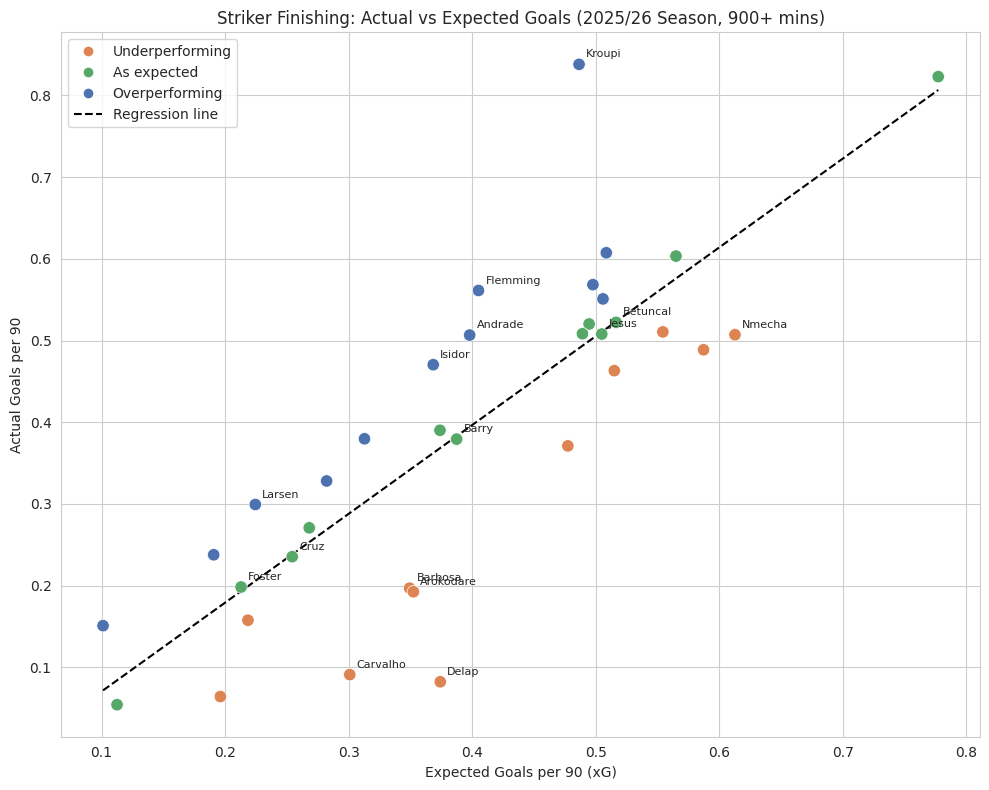

In [14]:
plt.figure(figsize=(10,8))

# Three-way coloring: under / as-expected / over
def get_color(residual, threshold=0.03):
    if residual < -threshold:
        return '#DD8452'  # underperforming, orange
    elif residual > threshold:
        return '#4C72B0'  # overperforming, blue
    else:
        return '#55A868'  # as-expected, green

colors = [get_color(r) for r in strikers_filtered['residual_per_90']]

plt.scatter(strikers_filtered['xg_per_90'], strikers_filtered['goals_per_90'],
            c=colors, s=80, edgecolor='white', linewidth=0.5, zorder=3)

x_line = np.linspace(strikers_filtered['xg_per_90'].min(), strikers_filtered['xg_per_90'].max(), 100)
y_line = reg90.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, color='black', linestyle='--', linewidth=1.5, zorder=2)

# Label extremes AND as-expected players
extremes = pd.concat([ranked90.head(5), ranked90.tail(5), as_expected])
for _, row in extremes.iterrows():
    plt.annotate(row['name'].split()[-1],
                 (row['xg_per_90'], row['goals_per_90']),
                 textcoords="offset points", xytext=(5,5), fontsize=8)

plt.xlabel("Expected Goals per 90 (xG)")
plt.ylabel("Actual Goals per 90")
plt.title("Striker Finishing: Actual vs Expected Goals (2025/26 Season, 900+ mins)")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#DD8452', markersize=8, label='Underperforming'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#55A868', markersize=8, label='As expected'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#4C72B0', markersize=8, label='Overperforming'),
    Line2D([0],[0], color='black', linestyle='--', label='Regression line')
]
plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()